In [ ]:
from pathlib import Path
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Текущая рабочая папка:', PROJECT_DIR)
data_json = PROJECT_DIR / 'data.json'
if data_json.exists():
    print('data.json найден')
else:
    print('data.json не найден — если запускаете ноутбук 01, положите его в текущую папку проекта:', PROJECT_DIR)
existing = sorted(p.name for p in ARTIFACT_DIR.iterdir())
if existing:
    print(f'В artifacts/ уже есть {len(existing)} файлов/папок:')
    for name in existing:
        print(' -', name)
else:
    print('Папка artifacts/ пока пустая, она заполнится после запуска обучающих ноутбуков.')

# 01 — Постановка задачи, данные, EDA и предобработка текстов

Разделы:
1. Постановка задачи  
2. Загрузка и описание данных: VK + HuggingFace sentiment dataset  
3. Разведочный анализ данных  
4. Предобработка текстов


## 1. Постановка задачи

Цель проекта — построить **Индекс цифрового счастья** для пользователей ВКонтакте по открытому цифровому следу: текстам постов, социальной активности, структуре связей и негативным паттернам поведения.

Трёхклассовая классификация тональности текста:

| Метка | Класс |
|---:|---|
| 0 | Негативный |
| 1 | Позитивный |
| 2 | Нейтральный |

Базовая формула:

$$
BaseIndex = 0.30 \cdot S_{network} + 0.20 \cdot S_{activity} + 0.50 \cdot S_{sentiment}
$$

Итоговая формула с корректировками:

$$
HappinessIndex = clip(BaseIndex \cdot P_{toxic} \cdot P_{showcase} - D_{insomnia}, 0, 1)
$$

Где:
- `P_toxic = 0.85`, если найдены токсичные/депрессивные сообщества, иначе `1.00`;
- `P_showcase = 0.90`, если подписчиков минимум в 5 раз больше, чем друзей, иначе `1.00`;
- `D_insomnia = 0.15 * night_posts_share`, где ночные посты — публикации с 01:00 до 05:00;
- `S_network` учитывает не только число друзей, но и графовые метрики по спискам ID друзей.

### Проверка зависимостей

In [8]:
import importlib.util
import subprocess
import sys
REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'datasets': 'datasets',
    'joblib': 'joblib',
}
missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Устанавливаются отсутствующие зависимости:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все зависимости доступны.')

Все зависимости доступны.


## Импорты и конфигурация

In [9]:
import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
ID2LABEL = {0: 'NEGATIVE', 1: 'POSITIVE', 2: 'NEUTRAL'}
LABEL2ID = {'NEGATIVE': 0, 'POSITIVE': 1, 'NEUTRAL': 2}
TOXIC_KEYWORDS = ['депрессия', 'грусть', 'боль', 'слезы', 'слёзы', 'одиночество','апатия', 'ненависть', 'суицид', 'смерть', 'безысходность']
sns.set_theme(style='whitegrid', palette='Set2')
EDA_PALETTE = sns.color_palette('Set2', 8)
EDA_CITY_CMAP = 'viridis'
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
set_seed(RANDOM_STATE)
print(f'Рабочая папка: {PROJECT_DIR}')
print(f'Папка артефактов: {ARTIFACT_DIR}')

Рабочая папка: /content/drive/MyDrive/happiness_formula
Папка артефактов: /content/drive/MyDrive/happiness_formula/artifacts


## 2. Загрузка и описание данных

In [10]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
DATA_JSON_CANDIDATES = [
    PROJECT_DIR / 'data.json',
    Path('/mnt/data/data.json')]
DATA_JSON = next((path for path in DATA_JSON_CANDIDATES if path.exists()), None)
if DATA_JSON is None:
    raise FileNotFoundError(
        'Не найден data.json. Положите файл рядом с ноутбуками или в /mnt/data/data.json.')
with open(DATA_JSON, 'r', encoding='utf-8') as file:
    raw_data = json.load(file)
print(f'Загружено сырых профилей VK: {len(raw_data)}')
print(f'Источник VK-данных: {DATA_JSON}')

Загружено сырых профилей VK: 743
Источник VK-данных: /content/drive/MyDrive/happiness_formula/data.json


In [11]:
def to_number(value, default: float = 0.0) -> float:
    try:
        if value is None or value == '':
            return default
        return float(value)
    except (TypeError, ValueError):
        return default
def extract_friend_ids(value) -> List[int]:
    if value is None:
        return []
    if isinstance(value, dict):
        if 'items' in value and isinstance(value['items'], list):
            value = value['items']
        else:
            value = list(value.values())
    if not isinstance(value, list):
        return []
    friend_ids = []
    for item in value:
        if isinstance(item, dict):
            item = item.get('id') or item.get('user_id')
        try:
            friend_ids.append(int(item))
        except (TypeError, ValueError):
            continue
    return sorted(set(friend_ids))
def parse_post_datetime(value, timezone: str = 'Europe/Moscow'):
    if value is None or value == '':
        return pd.NaT
    try:
        return pd.to_datetime(float(value), unit='s', utc=True).tz_convert(timezone)
    except (TypeError, ValueError, OverflowError):
        parsed = pd.to_datetime(value, errors='coerce', utc=True)
        if pd.isna(parsed):
            return pd.NaT
        return parsed.tz_convert(timezone)
users_list = []
posts_list = []
for user in raw_data:
    age = int(to_number(user.get('age'), 0))
    friend_ids = extract_friend_ids(user.get('friends'))
    friends_num = int(to_number(user.get('friends_num'), len(friend_ids)))
    followers_num = int(to_number(
        user.get('followers_num', user.get('followers_count', user.get('subscribers_num', 0))), 0))
    self_posts_num = int(to_number(user.get('self_posts_num'), 0))
    if not (18 <= age <= 35 and 0 < friends_num < 5000 and self_posts_num > 0):
        continue
    groups = user.get('groups', {}) or {}
    if isinstance(groups, list):
        group_iterable = groups
    else:
        group_iterable = groups.values()
    groups_text = ' '.join(
        f"{group.get('name', '')} {group.get('description', '')}"
        for group in group_iterable
        if isinstance(group, dict)).lower()
    has_toxic = any(keyword in groups_text for keyword in TOXIC_KEYWORDS)
    follower_friend_ratio = followers_num / max(friends_num, 1)
    showcase_account = follower_friend_ratio >= 5
    users_list.append({
        'user_id': int(user['id']),
        'city': user.get('city', 'Неизвестно'),
        'age': age,
        'gender': user.get('gender', 'Не указан'),
        'friends_num': friends_num,
        'followers_num': followers_num,
        'follower_friend_ratio': follower_friend_ratio,
        'showcase_account': showcase_account,
        'groups_num': int(to_number(user.get('groups_num'), 0)),
        'self_posts_num': self_posts_num,
        'reposts_num': int(to_number(user.get('reposts_num'), 0)),
        'has_toxic_groups': has_toxic,
        'groups_text': groups_text,
        'friend_ids_json': json.dumps(friend_ids, ensure_ascii=False),
        'friends_ids_available': len(friend_ids) > 0,
    })
    for post_id, post_data in (user.get('posts', {}) or {}).items():
        if not isinstance(post_data, dict):
            continue
        text = str(post_data.get('text', '')).strip()
        if len(text) <= 15:
            continue
        post_datetime = parse_post_datetime(post_data.get('date'))
        post_hour = np.nan if pd.isna(post_datetime) else int(post_datetime.hour)
        posts_list.append({
            'user_id': int(user['id']),
            'post_id': str(post_id),
            'text': text,
            'date_raw': post_data.get('date'),
            'post_datetime': '' if pd.isna(post_datetime) else post_datetime.isoformat(),
            'post_hour': post_hour,
            'is_night_post': bool(1 <= post_hour <= 5) if not pd.isna(post_hour) else False})
users_df = pd.DataFrame(users_list)
posts_df = pd.DataFrame(posts_list)
if users_df.empty:
    raise ValueError('После фильтрации не осталось пользователей. Проверьте age, friends_num и self_posts_num.')
night_share = (
    posts_df.groupby('user_id')['is_night_post']
    .mean()
    .reset_index()
    .rename(columns={'is_night_post': 'night_posts_share'}))
users_df = users_df.merge(night_share, on='user_id', how='left')
users_df['night_posts_share'] = users_df['night_posts_share'].fillna(0.0)
print(f'Пользователей после фильтрации: {len(users_df)}')
print(f'Постов для анализа: {len(posts_df)}')
print('\nРаспределение по городам:')
print(users_df['city'].value_counts().to_string())
print(f"\nГендерный состав: {users_df['gender'].value_counts().to_dict()}")
print(f"Средний возраст: {users_df['age'].mean():.1f} лет")
display(users_df.head())

Пользователей после фильтрации: 572
Постов для анализа: 15987

Распределение по городам:
city
Санкт-Петербург    135
Волгоград          102
Екатеринбург        95
Хабаровск           81
Казань              76
Москва              42
Новосибирск         41

Гендерный состав: {'female': 331, 'male': 241}
Средний возраст: 29.4 лет


,user_id,city,age,gender,friends_num,followers_num,follower_friend_ratio,showcase_account,groups_num,self_posts_num,reposts_num,has_toxic_groups,groups_text,friend_ids_json,friends_ids_available,night_posts_share
0,230173495,Москва,33,female,249,0,0.0,False,57,11,89,True,мяч и шайба мяч и шайба: футбол и хоккей 24/7\...,"[45552, 93832, 167745, 229898, 314501, 570602,...",True,0.000000
1,33545305,Москва,30,female,371,0,0.0,False,16,58,42,True,анастасия тарасова (костенко) № 4840332313 дми...,"[1011, 5892, 12756, 38870, 361908, 371559, 668...",True,0.041667
2,104916144,Москва,25,female,1862,0,0.0,False,699,98,2,True,сводки от ополчения новороссии добровольный до...,"[8791, 16446, 28005, 40601, 48276, 51079, 5487...",True,0.020408
3,641099221,Москва,31,male,1849,0,0.0,False,53,91,9,True,народный фронт народный фронт — общественное д...,"[5463, 6703, 19669, 20253, 27294, 28005, 28054...",True,0.000000
4,15087000,Москва,31,male,2761,0,0.0,False,87,83,17,True,газета.ru страница ведущего общественно-полити...,"[27407, 33549, 121106, 128361, 136414, 150549,...",True,0.053333


### Графовые признаки по спискам ID друзей

In [12]:
def decode_friend_ids(value: str) -> List[int]:
    try:
        decoded = json.loads(value)
        return [int(item) for item in decoded]
    except Exception:
        return []
def compute_observed_graph_metrics(users: pd.DataFrame) -> pd.DataFrame:
    """Строит не весь граф VK, а наблюдаемый подграф по пользователям из нашей выборки."""
    ids = set(users['user_id'].astype(int))
    friend_sets = {
        int(row.user_id): set(decode_friend_ids(row.friend_ids_json)) & ids - {int(row.user_id)}
        for row in users.itertuples(index=False)}
    adjacency = {user_id: set() for user_id in ids}
    for user_id, friends in friend_sets.items():
        for friend_id in friends:
            if friend_id in ids and friend_id != user_id:
                adjacency[user_id].add(friend_id)
                adjacency[friend_id].add(user_id)
    def local_clustering(user_id: int) -> float:
        neighbors = list(adjacency[user_id])
        degree = len(neighbors)
        if degree < 2:
            return 0.0
        possible_edges = degree * (degree - 1) / 2
        observed_edges = 0
        neighbor_sets = {node: adjacency[node] for node in neighbors}
        for i, left in enumerate(neighbors):
            for right in neighbors[i + 1:]:
                if right in neighbor_sets[left]:
                    observed_edges += 1
        return observed_edges / possible_edges
    component_size = {}
    visited = set()
    for start in ids:
        if start in visited:
            continue
        stack = [start]
        component = set()
        visited.add(start)
        while stack:
            node = stack.pop()
            component.add(node)
            for neighbor in adjacency[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    stack.append(neighbor)
        for node in component:
            component_size[node] = len(component)
    rows = []
    max_degree = max((len(values) for values in adjacency.values()), default=0)
    n_users = max(len(ids), 1)
    for user_id in users['user_id'].astype(int):
        degree = len(adjacency[user_id])
        degree_norm = degree / max(max_degree, 1)
        component_norm = component_size.get(user_id, 1) / n_users
        clustering = local_clustering(user_id)
        social_graph_norm = 0.50 * degree_norm + 0.30 * component_norm + 0.20 * clustering
        rows.append({
            'user_id': user_id,
            'observed_graph_degree': degree,
            'observed_graph_degree_norm': degree_norm,
            'observed_graph_component_share': component_norm,
            'observed_graph_clustering': clustering,
            'social_graph_norm': social_graph_norm})
    return pd.DataFrame(rows)
graph_df = compute_observed_graph_metrics(users_df)
users_df = users_df.merge(graph_df, on='user_id', how='left')
print('Графовые признаки построены по наблюдаемому подграфу VK-выборки.')
print(f"Доля пользователей с доступным списком friend IDs: {users_df['friends_ids_available'].mean():.1%}")
print(f"Средняя внутренняя степень: {users_df['observed_graph_degree'].mean():.2f}")
display(users_df[[
    'user_id', 'friends_num', 'followers_num', 'follower_friend_ratio',
    'showcase_account', 'night_posts_share', 'observed_graph_degree',
    'social_graph_norm',
]].head())

Графовые признаки построены по наблюдаемому подграфу VK-выборки.
Доля пользователей с доступным списком friend IDs: 100.0%
Средняя внутренняя степень: 0.61


,user_id,friends_num,followers_num,follower_friend_ratio,showcase_account,night_posts_share,observed_graph_degree,social_graph_norm
0,230173495,249,0,0.0,False,0.000000,1,0.072028
1,33545305,371,0,0.0,False,0.041667,1,0.072028
2,104916144,1862,0,0.0,False,0.020408,0,0.000524
3,641099221,1849,0,0.0,False,0.000000,0,0.000524
4,15087000,2761,0,0.0,False,0.053333,1,0.072028


In [13]:
print('Базовая статистика — датасет VK:')
summary_cols = [
    'age', 'friends_num', 'followers_num', 'follower_friend_ratio',
    'groups_num', 'self_posts_num', 'reposts_num', 'night_posts_share',
    'observed_graph_degree', 'social_graph_norm']
display(users_df[summary_cols].describe().round(3))

Базовая статистика — датасет VK:


,age,friends_num,followers_num,follower_friend_ratio,groups_num,self_posts_num,reposts_num,night_posts_share,observed_graph_degree,social_graph_norm
count,572.000,572.000,572.0,572.0,572.000,572.000,572.000,572.000,572.000,572.000
mean,29.376,857.012,0.0,0.0,196.684,52.168,16.066,0.088,0.612,0.033
std,3.959,1212.630,0.0,0.0,261.527,37.129,24.229,0.173,1.525,0.082
min,18.000,1.000,0.0,0.0,0.000,1.000,0.000,0.000,0.000,0.001
25%,27.000,118.750,0.0,0.0,27.000,15.000,0.000,0.000,0.000,0.001
50%,30.000,295.000,0.0,0.0,91.500,51.000,4.000,0.000,0.000,0.001
75%,33.000,889.750,0.0,0.0,240.250,92.250,22.000,0.111,1.000,0.040
max,35.000,4967.000,0.0,0.0,996.000,100.000,99.000,1.000,13.000,0.546


### Датасет 2: русскоязычный корпус тональности

Используется `k1tub/sentiment_dataset` из HuggingFace Datasets. Разметка: `0` — негативный, `1` — позитивный, `2` — нейтральный.

In [14]:
dataset = load_dataset('k1tub/sentiment_dataset')
df_sent = dataset['train'].to_pandas()
print(f"Всего записей в датасете: {len(df_sent):,}")
print(f"Распределение меток: {df_sent['label'].value_counts().sort_index().to_dict()}")
if 'src' in df_sent.columns:
    print(f"Источники текстов: {df_sent['src'].unique()}")
print('\nПримеры:')
for label, name in enumerate(TARGET_NAMES):
    example = df_sent[df_sent['label'] == label]['text'].iloc[0]
    print(f'[{name}] {example[:120]}...')

README.md:   0%|          | 0.00/3.02k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/96.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/290458 [00:00<?, ? examples/s]

Всего записей в датасете: 290,458
Распределение меток: {0: 96589, 1: 96877, 2: 96992}
Источники текстов: ['rureviews' 'anime' 'geo' 'sber' 'bank' 'rusentiment' 'kinopoisk' 'linis'
 'news' 'ru-reviews-classification' 'perekrestok']

Примеры:
[Негативный] Пальто красивое, но пришло с дырой в молнии. Просила выслать такую же, но продавец настаивал на открытии спора.
Али экс...
[Позитивный] отличная рубашка. на размер 46- 48 брала xxl...
[Нейтральный] Продавец отправил посылку на неверный адрес, пол месяца кормил завтраками что отправит повторно, но у него все время не ...


In [15]:
SAMPLE_PER_CLASS = 2500
df_sample = df_sent[df_sent['label'].isin([0, 1, 2])].copy()
df_sample = (
    df_sample
    .groupby('label', group_keys=False)
    .apply(lambda part: part.sample(min(len(part), SAMPLE_PER_CLASS), random_state=RANDOM_STATE))
    .reset_index(drop=True))
print(f'Итого для обучения/тестирования: {len(df_sample)} примеров')
print(f"Баланс классов: {df_sample['label'].value_counts().sort_index().to_dict()}")
display(df_sample.head())

Итого для обучения/тестирования: 7500 примеров
Баланс классов: {0: 2500, 1: 2500, 2: 2500}


,text,label,src
0,"Рассыпается на мелкие кусочки , когда в охлажд...",0,perekrestok
1,Были в данном заведении в середине апреля. В ц...,0,geo
2,"Заказала 11 сентября, пришли уже 25, цвет отли...",0,rureviews
3,хочешь себе такую?))),0,rusentiment
4,В целом хорошая точка пятерочки. Есть кассы са...,0,geo


## 3. Разведочный анализ данных

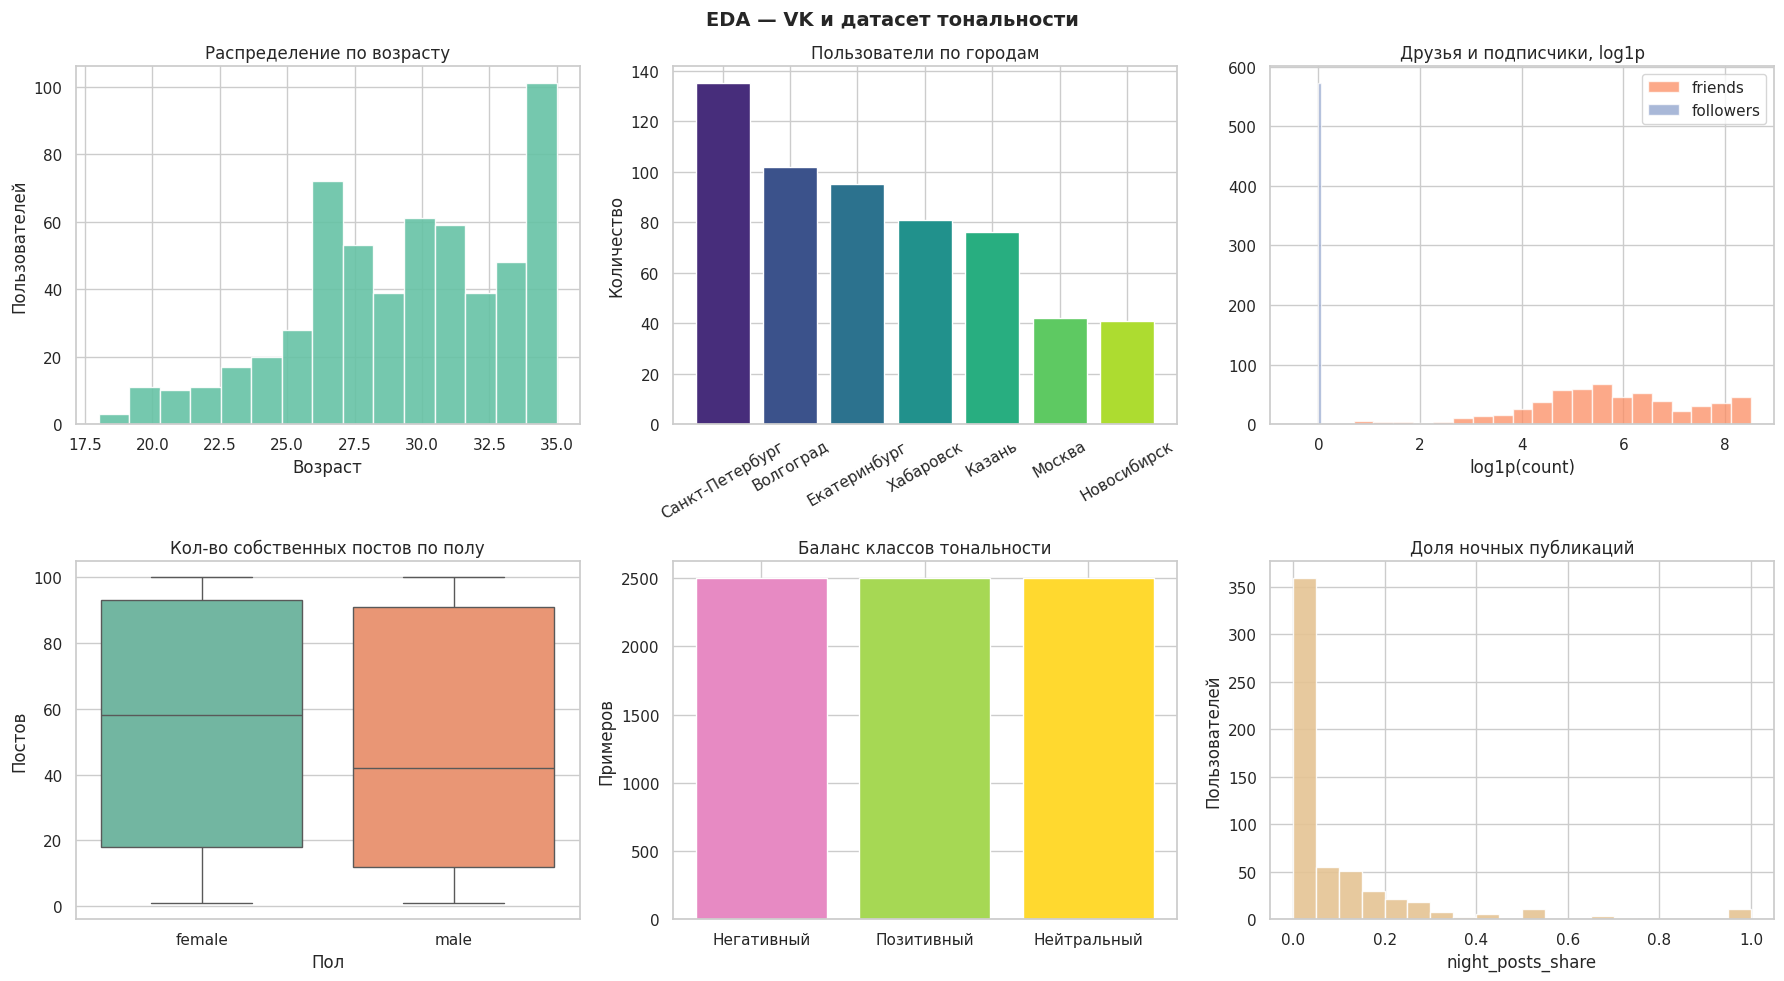

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — VK и датасет тональности', fontsize=14, fontweight='bold')
axes[0, 0].hist(users_df['age'], bins=15, color=EDA_PALETTE[0], edgecolor='white', alpha=0.9)
axes[0, 0].set_title('Распределение по возрасту')
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Пользователей')
city_counts = users_df['city'].value_counts()
city_colors = sns.color_palette(EDA_CITY_CMAP, len(city_counts))
axes[0, 1].bar(city_counts.index.astype(str), city_counts.values, color=city_colors, edgecolor='white')
axes[0, 1].set_title('Пользователи по городам')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].set_ylabel('Количество')
axes[0, 2].hist(np.log1p(users_df['friends_num']), bins=20, color=EDA_PALETTE[1], edgecolor='white', alpha=0.75, label='friends')
axes[0, 2].hist(np.log1p(users_df['followers_num']), bins=20, color=EDA_PALETTE[2], edgecolor='white', alpha=0.75, label='followers')
axes[0, 2].set_title('Друзья и подписчики, log1p')
axes[0, 2].set_xlabel('log1p(count)')
axes[0, 2].legend()
sns.boxplot(x='gender', y='self_posts_num', data=users_df, ax=axes[1, 0], hue='gender', palette='Set2', legend=False)
axes[1, 0].set_title('Кол-во собственных постов по полу')
axes[1, 0].set_xlabel('Пол')
axes[1, 0].set_ylabel('Постов')
label_counts = df_sample['label'].value_counts().sort_index()
label_colors = [EDA_PALETTE[3], EDA_PALETTE[4], EDA_PALETTE[5]]
axes[1, 1].bar(TARGET_NAMES, label_counts.values, color=label_colors, edgecolor='white')
axes[1, 1].set_title('Баланс классов тональности')
axes[1, 1].set_ylabel('Примеров')
axes[1, 2].hist(users_df['night_posts_share'], bins=20, color=EDA_PALETTE[6], edgecolor='white', alpha=0.9)
axes[1, 2].set_title('Доля ночных публикаций')
axes[1, 2].set_xlabel('night_posts_share')
axes[1, 2].set_ylabel('Пользователей')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Предобработка текстов

Для TF-IDF и xLSTM применяется очистка текста. Для RuBERT сохраняется исходный текст, потому что токенизатор трансформера умеет работать с регистром, пунктуацией и субсловами, а агрессивная очистка может удалить полезные сигналы.

In [17]:
def clean_text(text: str) -> str:
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^а-яёА-ЯЁa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

In [18]:
df_sample['text_clean'] = df_sample['text'].apply(clean_text)
print('Примеры очистки:')
for i in range(min(3, len(df_sample))):
    print('Исходный:  ', df_sample['text'].iloc[i][:120])
    print('Очищенный:', df_sample['text_clean'].iloc[i][:120])
    print()

Примеры очистки:
Исходный:   Рассыпается на мелкие кусочки , когда в охлажденном , до 4 градусов, виде. не понравилось.
Очищенный: рассыпается на мелкие кусочки когда в охлажденном до 4 градусов виде не понравилось

Исходный:   Были в данном заведении в середине апреля. В целом - неплохое место для завтрака на любой вкус. \n\nЧто понравилось:\nБо
Очищенный: были в данном заведении в середине апреля в целом неплохое место для завтрака на любой вкус n nчто понравилось nбольшой 

Исходный:   Заказала 11 сентября, пришли уже 25, цвет отличается от того что на фото
Очищенный: заказала 11 сентября пришли уже 25 цвет отличается от того что на фото



### Сохранение артефактов для следующих файлов

In [19]:
users_path = ARTIFACT_DIR / '01_vk_users.csv'
posts_path = ARTIFACT_DIR / '01_vk_posts.csv'
sentiment_path = ARTIFACT_DIR / '01_sentiment_sample.csv'
users_df.to_csv(users_path, index=False, encoding='utf-8-sig')
posts_df.to_csv(posts_path, index=False, encoding='utf-8-sig')
df_sample.to_csv(sentiment_path, index=False, encoding='utf-8-sig')
print(f'Сохранено: {users_path}')
print(f'Сохранено: {posts_path}')
print(f'Сохранено: {sentiment_path}')

Сохранено: /content/drive/MyDrive/happiness_formula/artifacts/01_vk_users.csv
Сохранено: /content/drive/MyDrive/happiness_formula/artifacts/01_vk_posts.csv
Сохранено: /content/drive/MyDrive/happiness_formula/artifacts/01_sentiment_sample.csv
